# Mini Demo: Tabular Classification & Time-series Forecasting

Notebook này gồm **2 phần demo tách biệt**:

1. **Tabular Data + Classification**  
   Bài toán: *Dự đoán hoạt động ngoài trời có nên diễn ra hay không*  
   Model: `DecisionTreeClassifier`

2. **Time-series Data + Forecasting**  
   Bài toán: *Dự đoán doanh thu ngày tiếp theo*  
   Model: `DecisionTreeRegressor`


## 0. Import thư viện cần dùng

Ta dùng:

- `pandas` để tạo, đọc và xử lý dữ liệu dạng bảng.
- `matplotlib` để vẽ biểu đồ.
- `scikit-learn` để train mô hình Decision Tree.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Import thư viện thành công!")


Import thư viện thành công!


# Phần 1 — Tabular Data + Classification

## Bài toán: Dự đoán hoạt động ngoài trời

Ta có một bảng dữ liệu thời tiết.  
Mỗi dòng tương ứng với một ngày.

Mục tiêu là dự đoán:

> Với điều kiện thời tiết hiện tại, **hoạt động ngoài trời có nên diễn ra hay không?**

Vì output là nhãn **Có / Không**, đây là bài toán **Classification**.


## 1.1. Tạo dữ liệu mẫu và lưu thành file CSV

Trong thực tế, dữ liệu thường có sẵn dưới dạng `.csv`, Excel hoặc database.  
Ở đây ta tạo nhanh một dataset nhỏ để demo.


In [ ]:
outdoor_data = pd.DataFrame({
    "Outlook": [
        "Sunny", "Sunny", "Overcast", "Rain", "Rain", "Rain", "Overcast",
        "Sunny", "Sunny", "Rain", "Sunny", "Overcast", "Overcast", "Rain"
    ],
    "Temperature": [
        "Hot", "Hot", "Hot", "Mild", "Cool", "Cool", "Cool",
        "Mild", "Cool", "Mild", "Mild", "Mild", "Hot", "Mild"
    ],
    "Humidity": [
        "High", "High", "High", "High", "Normal", "Normal", "Normal",
        "High", "Normal", "Normal", "Normal", "High", "Normal", "High"
    ],
    "Wind": [
        "Weak", "Strong", "Weak", "Weak", "Weak", "Strong", "Strong",
        "Weak", "Weak", "Weak", "Strong", "Strong", "Weak", "Strong"
    ],
    "Outdoor_Activity": [
        "No", "No", "Yes", "Yes", "Yes", "No", "Yes",
        "No", "Yes", "Yes", "Yes", "Yes", "Yes", "No"
    ]
})

outdoor_data.to_csv("outdoor_activity.csv", index=False)
print("Đã tạo file outdoor_activity.csv")


Đã tạo file outdoor_activity.csv


## 1.2. Đọc dữ liệu bằng Pandas

Ta đọc file `.csv` bằng `pd.read_csv()`.


In [ ]:
df_outdoor = pd.read_csv("outdoor_activity.csv")
df_outdoor


,Outlook,Temperature,Humidity,Wind,Outdoor_Activity
0,Sunny,Hot,High,Weak,No
1,Sunny,Hot,High,Strong,No
2,Overcast,Hot,High,Weak,Yes
3,Rain,Mild,High,Weak,Yes
4,Rain,Cool,Normal,Weak,Yes
5,Rain,Cool,Normal,Strong,No
6,Overcast,Cool,Normal,Strong,Yes
7,Sunny,Mild,High,Weak,No
8,Sunny,Cool,Normal,Weak,Yes
9,Rain,Mild,Normal,Weak,Yes


## 1.3. Quan sát nhanh dữ liệu

Một vài câu hỏi cần trả lời:

- Dataset có bao nhiêu dòng, bao nhiêu cột?
- Các cột đang có kiểu dữ liệu gì?
- Có missing value không?
- Nhãn `Outdoor_Activity` phân bố như thế nào?


In [ ]:
print("Kích thước dữ liệu:", df_outdoor.shape)

print("Thông tin dữ liệu:")
df_outdoor.info()

print("Số missing value ở từng cột:")
display(df_outdoor.isnull().sum())

print("Thống kê mô tả cho dữ liệu categorical:")
display(df_outdoor.describe(include="object"))

print("Phân bố nhãn Outdoor_Activity:")
display(df_outdoor["Outdoor_Activity"].value_counts())


Kích thước dữ liệu: (14, 5)
Thông tin dữ liệu:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Outlook           14 non-null     object
 1   Temperature       14 non-null     object
 2   Humidity          14 non-null     object
 3   Wind              14 non-null     object
 4   Outdoor_Activity  14 non-null     object
dtypes: object(5)
memory usage: 692.0+ bytes
Số missing value ở từng cột:


,0
Outlook,0
Temperature,0
Humidity,0
Wind,0
Outdoor_Activity,0


Thống kê mô tả cho dữ liệu categorical:


,Outlook,Temperature,Humidity,Wind,Outdoor_Activity
count,14,14,14,14,14
unique,3,3,2,2,2
top,Sunny,Mild,High,Weak,Yes
freq,5,6,7,8,9


Phân bố nhãn Outdoor_Activity:


,count
Outdoor_Activity,
Yes,9
No,5


## 1.4. Insight ban đầu từ dữ liệu

Ta có thể rút ra một vài nhận xét đơn giản:

- Dữ liệu gồm các cột điều kiện thời tiết.
- Output là `Outdoor_Activity`, gồm hai nhãn `Yes` và `No`.
- Các cột input đều là dữ liệu categorical.
- Vì output là nhãn rời rạc, ta dùng mô hình classification.


## 1.5. Vẽ bar chart cho nhãn cần dự đoán

Bar chart giúp ta xem nhanh số lượng mẫu thuộc từng nhãn.


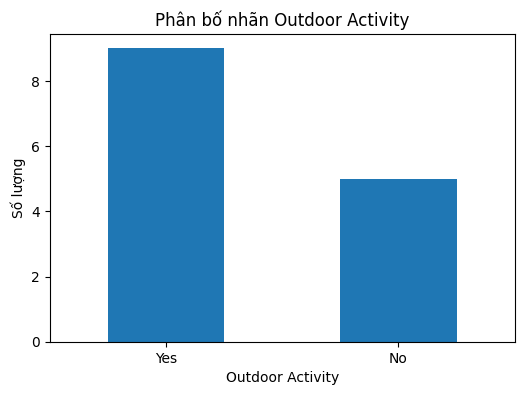

In [ ]:
label_counts = df_outdoor["Outdoor_Activity"].value_counts()

plt.figure(figsize=(6, 4))
label_counts.plot(kind="bar")
plt.title("Phân bố nhãn Outdoor Activity")
plt.xlabel("Outdoor Activity")
plt.ylabel("Số lượng")
plt.xticks(rotation=0)

plt.show()


## 1.6. Chuẩn bị dữ liệu để train model

Với bài toán này:

- `X`: các cột input gồm `Outlook`, `Temperature`, `Humidity`, `Wind`
- `y`: nhãn cần dự đoán `Outdoor_Activity`

Vì input là categorical, ta cần encode trước khi đưa vào mô hình.  
Ở đây dùng `OneHotEncoder` trong pipeline để xử lý tự động.


In [ ]:
X = df_outdoor[["Outlook", "Temperature", "Humidity", "Wind"]]
y = df_outdoor["Outdoor_Activity"]

categorical_features = ["Outlook", "Temperature", "Humidity", "Wind"]

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

clf_model = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", DecisionTreeClassifier(max_depth=3, random_state=42))
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

clf_model.fit(X_train, y_train)

print("Train xong DecisionTreeClassifier!")


Train xong DecisionTreeClassifier!


## 1.7. Đánh giá mô hình classification

Với bài classification, ta có thể xem:

- Accuracy
- Precision
- Recall
- F1-score

Vì dataset nhỏ nên kết quả chỉ mang tính minh họa.


In [ ]:
y_pred = clf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification report:")
print(classification_report(y_test, y_pred))


Accuracy: 0.4
Classification report:
              precision    recall  f1-score   support

          No       0.00      0.00      0.00         2
         Yes       0.50      0.67      0.57         3

    accuracy                           0.40         5
   macro avg       0.25      0.33      0.29         5
weighted avg       0.30      0.40      0.34         5



## 1.8. Dự đoán cho một ngày mới

Ví dụ: ngày mới có thời tiết `Rain`, nhiệt độ `Mild`, độ ẩm `High`, gió `Strong`.  
Mô hình sẽ dự đoán hoạt động ngoài trời có nên diễn ra hay không.


In [ ]:
new_day = pd.DataFrame({
    "Outlook": ["Rain"],
    "Temperature": ["Mild"],
    "Humidity": ["High"],
    "Wind": ["Strong"]
})

prediction = clf_model.predict(new_day)

display(new_day)
print("Dự đoán Outdoor Activity:", prediction[0])


,Outlook,Temperature,Humidity,Wind
0,Rain,Mild,High,Strong


Dự đoán Outdoor Activity: No


## 1.9. Minh họa cây quyết định

Ta có thể vẽ cây quyết định để thấy mô hình ra quyết định theo các nhánh.

Lưu ý: phần này chỉ để minh họa, không cần đi sâu vào thuật toán.


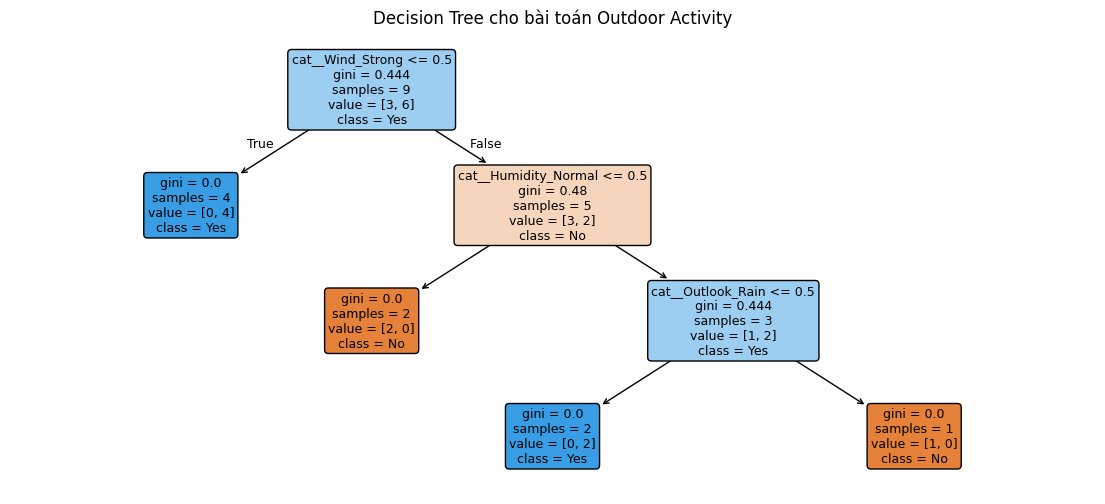

In [ ]:
trained_tree = clf_model.named_steps["model"]
feature_names = clf_model.named_steps["preprocess"].get_feature_names_out()

plt.figure(figsize=(14, 6))
plot_tree(
    trained_tree,
    feature_names=feature_names,
    class_names=trained_tree.classes_,
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title("Decision Tree cho bài toán Outdoor Activity")
plt.show()


# Phần 2 — Time-series Data + Forecasting

## Bài toán: Dự đoán doanh thu ngày tiếp theo

Ta có dữ liệu doanh thu theo ngày.  
Mục tiêu là dự đoán:

> Dựa vào doanh thu các ngày trước, **doanh thu ngày tiếp theo khoảng bao nhiêu?**

Vì output là một giá trị số trong tương lai, đây là bài toán **Forecasting**.  
Trong demo này, ta dùng `DecisionTreeRegressor` để minh họa cách giải đơn giản.


## 2.1. Tạo dữ liệu time-series ban đầu

Dữ liệu ban đầu chỉ có:

- `date`: ngày ghi nhận
- `sales`: doanh thu trong ngày

Đây là dạng dữ liệu time-series vì mỗi dòng gắn với một mốc thời gian.


In [ ]:
sales_data = pd.DataFrame({
    "date": pd.date_range(start="2026-05-01", periods=20, freq="D"),
    "sales": [
        105, 112, 108, 120, 128,
        125, 132, 138, 135, 145,
        150, 148, 155, 160, 158,
        168, 172, 170, 180, 185
    ]
})

sales_data.to_csv("daily_sales.csv", index=False)
print("Đã tạo file daily_sales.csv")


Đã tạo file daily_sales.csv


## 2.2. Đọc dữ liệu bằng Pandas

Ta đọc lại file `daily_sales.csv`.


In [ ]:
df_sales = pd.read_csv("daily_sales.csv")
df_sales["date"] = pd.to_datetime(df_sales["date"])
df_sales


,date,sales
0,2026-05-01,105
1,2026-05-02,112
2,2026-05-03,108
3,2026-05-04,120
4,2026-05-05,128
5,2026-05-06,125
6,2026-05-07,132
7,2026-05-08,138
8,2026-05-09,135
9,2026-05-10,145


## 2.3. Quan sát dữ liệu ban đầu

Ta kiểm tra:

- Số dòng, số cột.
- Kiểu dữ liệu.
- Missing value.
- Thống kê mô tả của cột doanh thu.


In [ ]:
print("Kích thước dữ liệu:", df_sales.shape)

print("Thông tin dữ liệu:")
df_sales.info()

print("Số missing value ở từng cột:")
display(df_sales.isnull().sum())

print("Thống kê mô tả:")
display(df_sales.describe())


Kích thước dữ liệu: (20, 2)
Thông tin dữ liệu:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    20 non-null     datetime64[ns]
 1   sales   20 non-null     int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 452.0 bytes
Số missing value ở từng cột:


,0
date,0
sales,0


Thống kê mô tả:


,date,sales
count,20,20.00000
mean,2026-05-10 12:00:00,144.70000
min,2026-05-01 00:00:00,105.00000
25%,2026-05-05 18:00:00,127.25000
50%,2026-05-10 12:00:00,146.50000
75%,2026-05-15 06:00:00,162.00000
max,2026-05-20 00:00:00,185.00000
std,NaN,23.97828


## 2.4. Vẽ line chart cho doanh thu theo ngày

Với time-series data, line chart thường phù hợp vì giúp ta thấy xu hướng tăng/giảm theo thời gian.


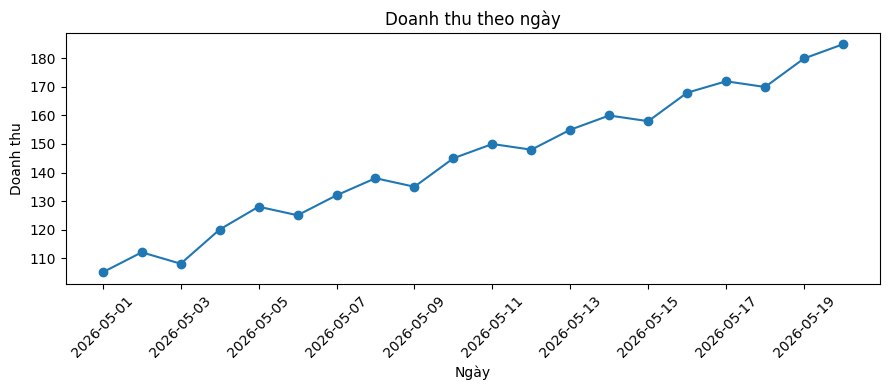

In [ ]:
plt.figure(figsize=(9, 4))
plt.plot(df_sales["date"], df_sales["sales"], marker="o")
plt.title("Doanh thu theo ngày")
plt.xlabel("Ngày")
plt.ylabel("Doanh thu")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 2.5. Vì sao cần tạo thêm các cột quá khứ?

Dữ liệu ban đầu chỉ có:

| date | sales |
|---|---|

Nếu đưa trực tiếp vào Decision Tree, mô hình chỉ thấy từng dòng riêng lẻ.  
Nhưng với time-series, doanh thu ngày mai thường liên quan đến doanh thu các ngày trước.

Vì vậy ta tạo thêm các đặc trưng từ quá khứ:

- `sales_lag_1`: doanh thu ngày hôm qua
- `sales_lag_2`: doanh thu 2 ngày trước
- `rolling_mean_3`: doanh thu trung bình 3 ngày gần nhất
- `day_of_week`: thứ trong tuần
- `sales_next_day`: doanh thu ngày tiếp theo cần dự đoán

Ý tưởng là chuyển dữ liệu time-series thành dạng bảng để mô hình học được.


In [ ]:
df_features = df_sales.copy()

# Doanh thu của 1 ngày trước
df_features["sales_lag_1"] = df_features["sales"].shift(1)

# Doanh thu của 2 ngày trước
df_features["sales_lag_2"] = df_features["sales"].shift(2)

# Trung bình doanh thu 3 ngày gần nhất
df_features["rolling_mean_3"] = df_features["sales"].rolling(window=3).mean()

# Thứ trong tuần: Monday=0, Sunday=6
df_features["day_of_week"] = df_features["date"].dt.dayofweek

# Doanh thu ngày tiếp theo cần dự đoán
df_features["sales_next_day"] = df_features["sales"].shift(-1)

df_features


,date,sales,sales_lag_1,sales_lag_2,rolling_mean_3,day_of_week,sales_next_day
0,2026-05-01,105,NaN,NaN,NaN,4,112.0
1,2026-05-02,112,105.0,NaN,NaN,5,108.0
2,2026-05-03,108,112.0,105.0,108.333333,6,120.0
3,2026-05-04,120,108.0,112.0,113.333333,0,128.0
4,2026-05-05,128,120.0,108.0,118.666667,1,125.0
5,2026-05-06,125,128.0,120.0,124.333333,2,132.0
6,2026-05-07,132,125.0,128.0,128.333333,3,138.0
7,2026-05-08,138,132.0,125.0,131.666667,4,135.0
8,2026-05-09,135,138.0,132.0,135.000000,5,145.0
9,2026-05-10,145,135.0,138.0,139.333333,6,150.0


## 2.6. Loại bỏ các dòng bị thiếu sau khi tạo feature

Khi dùng `shift()` và `rolling()`, một số dòng đầu/cuối sẽ bị thiếu giá trị.

Ví dụ:

- Dòng đầu tiên không có `sales_lag_1`.
- Hai dòng đầu chưa đủ dữ liệu để tính `rolling_mean_3`.
- Dòng cuối không có `sales_next_day`.

Ta sẽ loại bỏ các dòng thiếu để train model.


In [ ]:
df_model_sales = df_features.dropna().reset_index(drop=True)
df_model_sales


,date,sales,sales_lag_1,sales_lag_2,rolling_mean_3,day_of_week,sales_next_day
0,2026-05-03,108,112.0,105.0,108.333333,6,120.0
1,2026-05-04,120,108.0,112.0,113.333333,0,128.0
2,2026-05-05,128,120.0,108.0,118.666667,1,125.0
3,2026-05-06,125,128.0,120.0,124.333333,2,132.0
4,2026-05-07,132,125.0,128.0,128.333333,3,138.0
5,2026-05-08,138,132.0,125.0,131.666667,4,135.0
6,2026-05-09,135,138.0,132.0,135.000000,5,145.0
7,2026-05-10,145,135.0,138.0,139.333333,6,150.0
8,2026-05-11,150,145.0,135.0,143.333333,0,148.0
9,2026-05-12,148,150.0,145.0,147.666667,1,155.0


## 2.7. Chuẩn bị dữ liệu để train DecisionTreeRegressor

Với bài toán forecasting này:

- `X`: các feature quá khứ và đặc trưng thời gian
- `y`: `sales_next_day`

Ta chia train/test theo đúng thứ tự thời gian, không shuffle.


In [ ]:
feature_cols = ["sales_lag_1", "sales_lag_2", "rolling_mean_3", "day_of_week"]

X_sales = df_model_sales[feature_cols]
y_sales = df_model_sales["sales_next_day"]

# Chia theo thứ tự thời gian: phần đầu để train, phần cuối để test
split_index = int(len(df_model_sales) * 0.75)

X_train_sales = X_sales.iloc[:split_index]
X_test_sales = X_sales.iloc[split_index:]

y_train_sales = y_sales.iloc[:split_index]
y_test_sales = y_sales.iloc[split_index:]

reg_model = DecisionTreeRegressor(max_depth=3, random_state=42)
reg_model.fit(X_train_sales, y_train_sales)

print("Train xong DecisionTreeRegressor!")


Train xong DecisionTreeRegressor!


## 2.8. Đánh giá mô hình forecasting

Với bài toán dự đoán giá trị số, ta có thể dùng:

- MAE: sai số tuyệt đối trung bình
- RMSE: căn bậc hai của sai số bình phương trung bình
- R²: mức độ giải thích biến động của dữ liệu

Vì dataset nhỏ nên kết quả chỉ dùng để minh họa quy trình.


In [ ]:
sales_pred = reg_model.predict(X_test_sales)

mae = mean_absolute_error(y_test_sales, sales_pred)
rmse = mean_squared_error(y_test_sales, sales_pred) ** 0.5
r2 = r2_score(y_test_sales, sales_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

result_compare = pd.DataFrame({
    "actual_sales_next_day": y_test_sales.values,
    "predicted_sales_next_day": sales_pred
})

result_compare


MAE: 16.0
RMSE: 17.25108692227826
R²: -6.153846153846154


,actual_sales_next_day,predicted_sales_next_day
0,168.0,159.0
1,172.0,159.0
2,170.0,159.0
3,180.0,159.0
4,185.0,159.0


## 2.9. Vẽ biểu đồ so sánh giá trị thật và giá trị dự đoán

Biểu đồ giúp ta nhìn nhanh mô hình dự đoán gần hay xa so với giá trị thực tế.


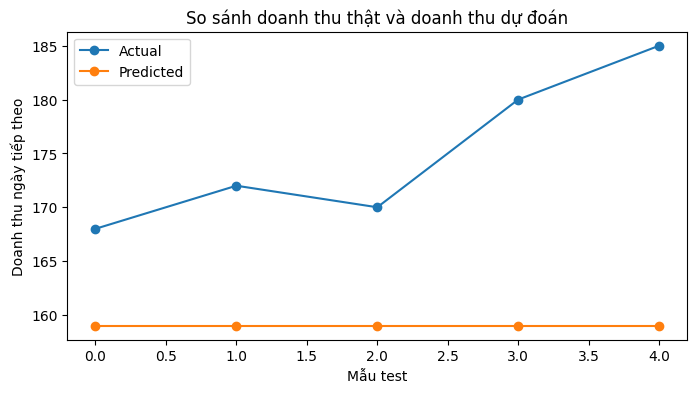

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(result_compare["actual_sales_next_day"].values, marker="o", label="Actual")
plt.plot(result_compare["predicted_sales_next_day"].values, marker="o", label="Predicted")
plt.title("So sánh doanh thu thật và doanh thu dự đoán")
plt.xlabel("Mẫu test")
plt.ylabel("Doanh thu ngày tiếp theo")
plt.legend()
plt.show()


## 2.10. Dự đoán doanh thu ngày tiếp theo

Để dự đoán ngày tiếp theo sau ngày cuối cùng trong dataset, ta tạo một dòng input mới từ các ngày gần nhất:

- `sales_lag_1`: doanh thu hôm nay
- `sales_lag_2`: doanh thu hôm qua
- `rolling_mean_3`: trung bình 3 ngày gần nhất
- `day_of_week`: thứ của ngày cần dự đoán


In [ ]:
last_date = df_sales["date"].iloc[-1]
next_date = last_date + pd.Timedelta(days=1)

latest_sales = df_sales["sales"].iloc[-1]
previous_sales = df_sales["sales"].iloc[-2]
rolling_mean_3 = df_sales["sales"].iloc[-3:].mean()
next_day_of_week = next_date.dayofweek

next_day_features = pd.DataFrame({
    "sales_lag_1": [latest_sales],
    "sales_lag_2": [previous_sales],
    "rolling_mean_3": [rolling_mean_3],
    "day_of_week": [next_day_of_week]
})

predicted_next_sales = reg_model.predict(next_day_features)[0]

display(next_day_features)
print("Ngày cần dự đoán:", next_date.date())
print("Doanh thu dự đoán:", round(predicted_next_sales, 2))


,sales_lag_1,sales_lag_2,rolling_mean_3,day_of_week
0,185,180,178.333333,3


Ngày cần dự đoán: 2026-05-21
Doanh thu dự đoán: 159.0
